# Week 10 – Colab 1: Transfer Learning Basics

In this notebook you will:

1. Load a **pre-trained ResNet18** model in PyTorch  
2. Freeze its layers and replace the final classification layer  
3. Train the new classifier on the CIFAR-10 dataset  
4. Think about how this kind of model could be used in a creative robotics context

> 💡 Don't worry if some of the code looks long – you mostly just need to **run cells** and then **experiment with a few marked parameters**.


In [ ]:
#@title  Setup: Imports and Device

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Use GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [ ]:
#@title  Load CIFAR-10 Dataset

# Transform: resize to 224x224 (ResNet input), convert to tensor, normalise
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    # These are standard ImageNet normalisation values
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Download CIFAR-10 training and test datasets
train_dataset = torchvision.datasets.CIFAR10(root="./data", train=True,
                                             download=True, transform=transform)

test_dataset = torchvision.datasets.CIFAR10(root="./data", train=False,
                                            download=True, transform=transform)

# ==== STUDENT: TRY CHANGING THESE VALUES ====
batch_size = 64  # Try 32, 128, etc.

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

classes = train_dataset.classes  # CIFAR-10 has 10 classes
print("Classes:", classes)


100%|██████████| 170M/170M [00:03<00:00, 43.8MB/s]


Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


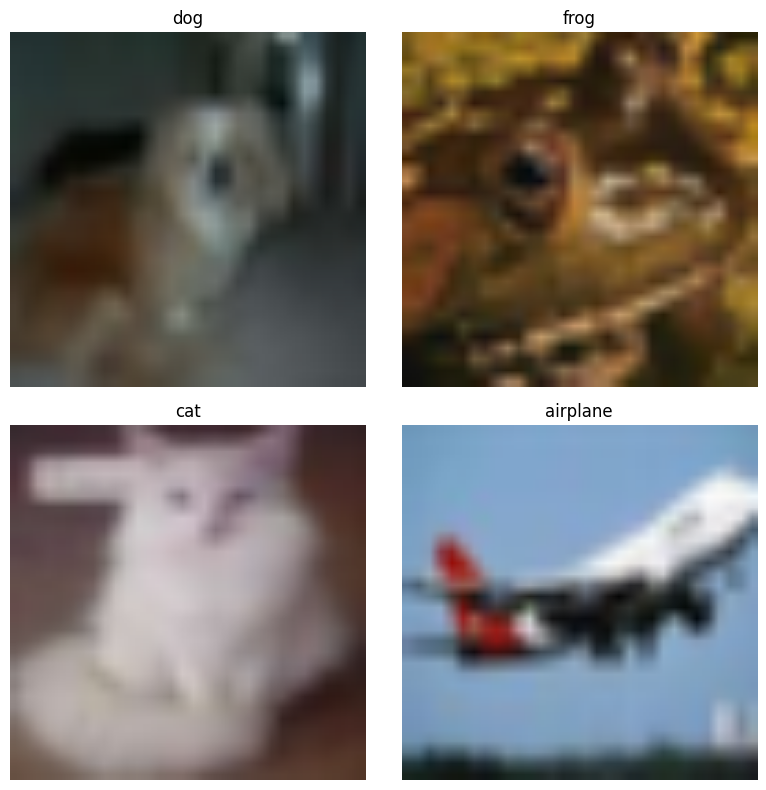

In [ ]:
#@title  Visualise Some Training Images (Optional)

def imshow(img):
    # Un-normalise then show
    img = img.clone()
    img = img * torch.tensor([0.229, 0.224, 0.225]).view(3,1,1) + \
              torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    img = img.clamp(0, 1)
    plt.imshow(img.permute(1, 2, 0))
    plt.axis("off")

data_iter = iter(train_loader)
images, labels = next(data_iter)

# Show first 4 images
plt.figure(figsize=(8, 8))
for i in range(4):
    plt.subplot(2, 2, i + 1)
    imshow(images[i])
    plt.title(classes[labels[i]])
plt.tight_layout()
plt.show()


In [ ]:
#@title  Load Pre-Trained ResNet18 and Turn It into a Feature Extractor

from torchvision import models

# Load ResNet18 with ImageNet pre-trained weights
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze all parameters so we don't change the pre-trained weights
for param in model.parameters():
    param.requires_grad = False

# ==== STUDENT: IMPORTANT PLACE TO MODIFY ====
# By default we match CIFAR-10 (10 classes).
# If you later use your own dataset with a different number of classes,
# change `num_classes` accordingly.
num_classes = 10  # CIFAR-10 has 10 classes

# Replace the final fully-connected layer
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)

model = model.to(device)
print(model)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 182MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
#@title Loss Function and Optimiser

criterion = nn.CrossEntropyLoss()

# We only pass parameters that require gradients (the new fc layer)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                       lr=1e-3)  # ==== STUDENT: TRY CHANGING LEARNING RATE ====

print("Number of trainable parameters:",
      sum(p.numel() for p in model.parameters() if p.requires_grad))


Number of trainable parameters: 5130


In [ ]:
#@title Train the Model (Feature Extractor)

# ==== STUDENT: TRY CHANGING NUMBER OF EPOCHS ====
num_epochs = 2  # Start small (e.g. 1–3)

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = correct / total

    print(f"Epoch [{epoch+1}/{num_epochs}] - "
          f"Loss: {epoch_loss:.4f} - Train Acc: {epoch_acc:.4f}")


Epoch [1/2] - Loss: 0.8291 - Train Acc: 0.7321
Epoch [2/2] - Loss: 0.6183 - Train Acc: 0.7875


In [ ]:
#@title  Evaluate on Test Set

model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

test_acc = correct / total
print(f"Test Accuracy: {test_acc:.4f}")


Test Accuracy: 0.7886


## Reflection: Linking to Creative Robotics

Answer in your own words (a few bullet points is fine):

1. How could a **10-class classifier** like this be used in a robotic system?
2. If you replaced CIFAR-10 with your own dataset (e.g. props in your project),
   what might your **custom classes** be?
3. Would you rather freeze most layers (like we did here) or try fine-tuning more layers?
   Why?
